In [1]:
# Cell 1 — load all metrics files
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

baseline = pd.read_csv('../results/metrics/baseline_metrics.csv')
ensemble = pd.read_csv('../results/metrics/ensemble_ml_metrics.csv')
boosting = pd.read_csv('../results/metrics/boosting_metrics.csv')
stacking = pd.read_csv('../results/metrics/stacking_metrics.csv')

all_results = pd.concat([baseline, ensemble, boosting, stacking], ignore_index=True)
all_results = all_results.drop_duplicates(subset='model', keep='last')
all_results = all_results.sort_values('recall', ascending=False)
print(all_results)

all_results.to_csv('../results/metrics/all_models_comparison.csv', index=False)

                                       model  accuracy  precision    recall  \
4                                        SVM  0.677037   0.490040  0.577465   
0                        Logistic Regression  0.672593   0.484127  0.572770   
5       Logistic Regression (L1 Regularized)  0.671111   0.482213  0.572770   
12  Stacking Ensemble (RF+XGB+LGBM → LogReg)  0.693333   0.512931  0.558685   
7                                   LightGBM  0.668148   0.477733  0.553991   
10                       LightGBM (from 05b)  0.668148   0.477733  0.553991   
18                     LightGBM (standalone)  0.668148   0.477733  0.553991   
6                              Random Forest  0.711111   0.542056  0.544601   
16                Random Forest (standalone)  0.711111   0.542056  0.544601   
8                                    XGBoost  0.705185   0.532710  0.535211   
9                         XGBoost (from 05b)  0.705185   0.532710  0.535211   
1                              Decision Tree  0.6933

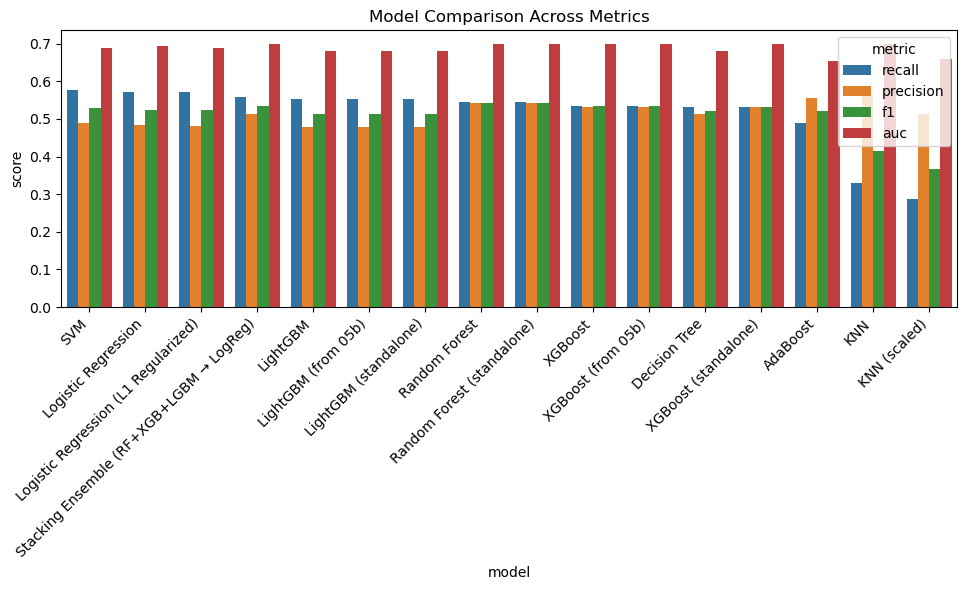

In [4]:
# Cell 2 — comparison chart
plt.figure(figsize=(10, 6))
melted = all_results.melt(id_vars='model', value_vars=['recall', 'precision', 'f1', 'auc'],
                            var_name='metric', value_name='score')
sns.barplot(data=melted, x='model', y='score', hue='metric')
plt.xticks(rotation=45, ha='right')
plt.title('Model Comparison Across Metrics')
plt.tight_layout()
plt.show()

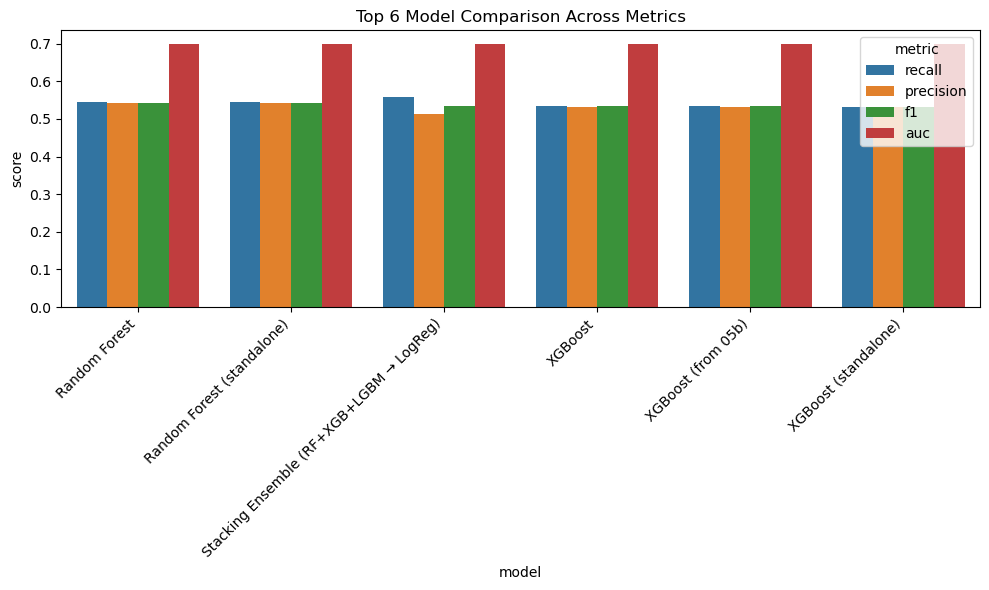

In [5]:
# Cell 2 — comparison chart (Top 6 Models)
plt.figure(figsize=(10, 6))

# Filter for the top 6 models based on F1 score (change 'f1' to 'auc' or another metric if preferred)
top_6_models = all_results.nlargest(6, 'f1')

# Melt the top 6 dataset
melted = top_6_models.melt(
    id_vars='model', 
    value_vars=['recall', 'precision', 'f1', 'auc'],
    var_name='metric', 
    value_name='score'
)

sns.barplot(data=melted, x='model', y='score', hue='metric')
plt.xticks(rotation=45, ha='right')
plt.title('Top 6 Model Comparison Across Metrics')
plt.tight_layout()
plt.show()

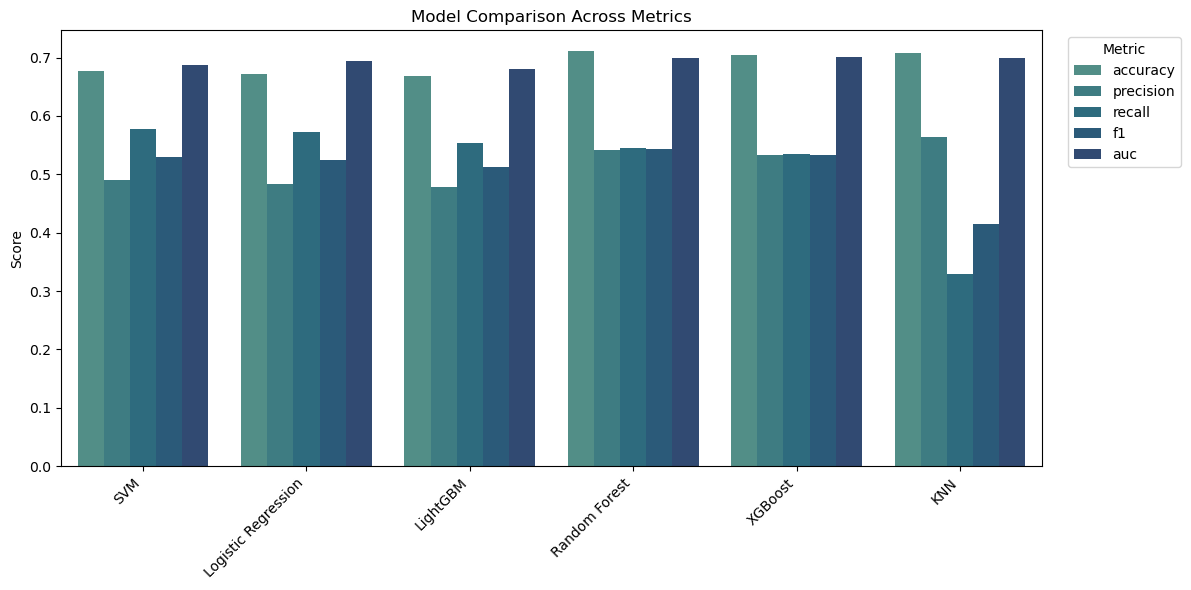

In [13]:
#top 6 model counting xgboost,xgboost stanadlone as one like that
# Cell 2 — comparison chart (models in table only, distinct blue shades)
plt.figure(figsize=(12, 6))

models_to_show = [
    'Stacking Ensemble (RF+XGB+LGBM -> LogReg)',
    'XGBoost',
    'Random Forest',
    'KNN',
    'Logistic Regression',
    'SVM',
    'LightGBM'
]

filtered_results = all_results[all_results['model'].isin(models_to_show)]

melted = filtered_results.melt(
    id_vars='model',
    value_vars=['accuracy', 'precision', 'recall', 'f1', 'auc'],
    var_name='metric',
    value_name='score'
)

palette = ['#0072B2', '#E69F00', '#009E73', '#CC79A7', '#D55E00']

sns.barplot(data=melted, x='model', y='score', hue='metric', palette=blue_palette)
plt.xticks(rotation=45, ha='right')
plt.title('Model Comparison Across Metrics')
plt.ylabel('Score')
plt.xlabel('')
plt.legend(title='Metric', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [3]:
# Cell 3 — identify best model
best_row = all_results.iloc[0]
print(f"Best model by recall: {best_row['model']} (recall={best_row['recall']:.3f}, AUC={best_row['auc']:.3f})")

Best model by recall: SVM (recall=0.577, AUC=0.688)
